In [1]:
import os
import sys
from pathlib import Path

#export PYTHONPATH=$PYTHONPATH:/home/nishi/local/git-download/lerobot/src
# パスを通す（お使いの環境に合わせて絶対パスに書き換えてください）
lerobot_path = "/home/nishi/local/git-download/lerobot"
sys.path.append(os.path.join(lerobot_path, "src"))

from lerobot.configs.train import TrainPipelineConfig
from lerobot.scripts.lerobot_train import train
from lerobot.configs.policies import PreTrainedConfig


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

frame.keys(): dict_keys(['observation.images.cam_high', 'observation.images.cam_left_wrist', 'observation.images.cam_low', 'observation.images.cam_right_wrist', 'observation.state', 'observation.effort', 'action', 'episode_index', 'frame_index', 'timestamp', 'next.done', 'index', 'task_index', 'task'])


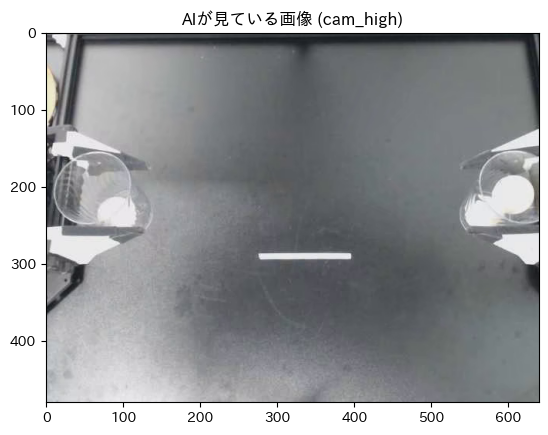

--- ロボットの今の状態 (observation.state) ---
tensor([ 0.0015, -0.9664,  1.1873, -0.0015, -0.2915,  0.0015,  0.9967, -0.0061,
        -0.9664,  1.1873,  0.0000, -0.2915, -0.0015,  0.9969])

--- 人間が教えた『次の動き』 (action) ---
tensor([-0.0138, -0.9526,  1.1980, -0.0015, -0.3206,  0.0123,  0.1330, -0.0107,
        -0.9557,  1.1658,  0.0015, -0.2961,  0.0031,  0.2010])


In [2]:
import matplotlib.pyplot as plt
import japanize_matplotlib # これを足すだけで日本語が使えるようになります
import torch

from lerobot.datasets.lerobot_dataset import LeRobotDataset

# データセットを直接読み込む
dataset = LeRobotDataset("lerobot/aloha_static_pingpong_test")

# 最初の1コマ（1ステップ分）をのぞき見
frame = dataset[0]

print('frame.keys():',frame.keys())

# 2. 画像を表示してみる (PyTorchの [C, H, W] 形式を [H, W, C] に変換)
img = frame["observation.images.cam_high"].permute(1, 2, 0)
plt.imshow(img)
plt.title("AIが見ている画像 (cam_high)")
plt.show()

# 3. 数値データを詳しく見る
print("--- ロボットの今の状態 (observation.state) ---")
print(frame["observation.state"]) 
# ↑ 14個の数字: [左腕の7関節, 右腕の7関節] の角度(ラジアン)です

print("\n--- 人間が教えた『次の動き』 (action) ---")
print(frame["action"])
# ↑ これをAIは「正解」として学習しています


#print("カメラ画像:", frame["observation.images.top"].shape) # [3, 480, 640] のような行列
#print("アームの角度:", frame["observation.state"])        # 14個の数字の羅列
#print("人間が出した命令:", frame["action"])               # 次に動かすべき角度

Episode 0 の範囲: 0 から 599 フレームまで


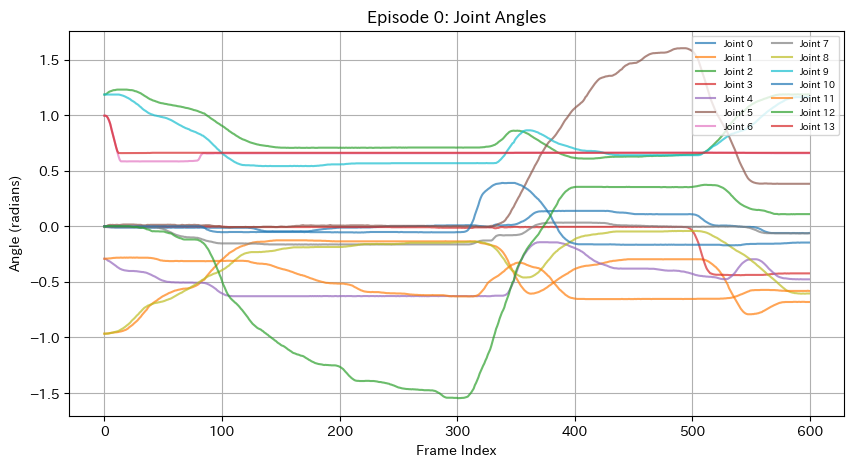

In [3]:
#pyplot as plt
import matplotlib.pyplot as plt
import numpy as np

# 1. 最初のエピソード（episode 0）に属するデータのインデックスを抽出
# 全データの中で episode_index が 0 の場所を探します
all_episode_indices = dataset.hf_dataset["episode_index"]
indices = np.where(np.array(all_episode_indices) == 0)[0]
start_idx, end_idx = indices[0], indices[-1]

print(f"Episode 0 の範囲: {start_idx} から {end_idx} フレームまで")

# 2. その範囲の関節角度を取り出す
states = []
for i in range(start_idx, end_idx + 1):
    states.append(dataset[i]["observation.state"].numpy())
states = np.array(states)

# 3. グラフ描画
plt.figure(figsize=(10, 5))
for i in range(14):
    plt.plot(states[:, i], label=f"Joint {i}", alpha=0.7)

plt.title("Episode 0: Joint Angles")
plt.xlabel("Frame Index")
plt.ylabel("Angle (radians)")
plt.grid(True)
# 凡例が多すぎるので主要なものだけに絞るか、外に出します
plt.legend(loc='upper right', fontsize='x-small', ncol=2)
plt.show()


# 下記コードを、jupyter notebook で、エミュレートします。  

python -m lerobot.scripts.lerobot_train \  
  --policy.type act \  
  --dataset.repo_id lerobot/aloha_static_pingpong_test \  
  --output_dir ./outputs/train/pingpong_test \  
  --batch_size 4 \  
  --policy.device cuda \  
  --policy.repo_id onchan_tosa/pingpong_test_model \  
  --save_checkpoint True \  
  --save_freq 1000  


In [4]:
import draccus
from lerobot.configs.train import TrainPipelineConfig
from lerobot.scripts.lerobot_train import train

config_dict = {
    # dataset_repo_id ではなく、dataset 階層の中の repo_id
    "dataset": {
        "repo_id": "lerobot/aloha_static_pingpong_test",
    },
    "policy": {
        "type": "act",
        "repo_id": "onchan_tosa/pingpong_test_model",
        "device": "cuda",
    },
    "output_dir": "outputs/train/pingpong_test",
    "batch_size": 4,
    "num_workers": 0,  # ← これを追加！並列処理を止めてエラーを回避します　jupyter notebook の時での、指定
    "save_checkpoint": True,
    "save_freq": 1000,
}

# 変換実行
cfg = draccus.decode(TrainPipelineConfig, config_dict)

# 動作確認（ここが通れば Loading dataset... が出ます！）
if False:
    train(cfg)



In [5]:
from lerobot.scripts.lerobot_train import make_policy

# 2. 脳（Policy）を構築
# 第2引数は「meta」として渡します
policy = make_policy(cfg.policy, dataset.meta)

# 3. 脳の設計図を表示
print(policy)


ACTPolicy(
  (model): ACT(
    (vae_encoder): ACTEncoder(
      (layers): ModuleList(
        (0-3): 4 x ACTEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
          )
          (linear1): Linear(in_features=512, out_features=3200, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=3200, out_features=512, bias=True)
          (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
      (norm): Identity()
    )
    (vae_encoder_cls_embed): Embedding(1, 512)
    (vae_encoder_robot_state_input_proj): Linear(in_features=14, out_features=512, bias=True)
    (vae_encoder_action_input_proj): Linear(in_features=14, out_features=512, bi

In [6]:
policy.to("cuda")
policy.eval()

# 2. 脳の入り口（カメラ名）を確認してデータをまとめる
# ACTは observation.images をリスト形式で一気に読み込みます
cam_keys = ["observation.images.cam_high"] # dataset.meta.camera_keys などから取得

frame = dataset[0]
batch = {
    # 脳が探している "observation.images" というキーに、画像のリストを入れる
    "observation.images": [frame[k].unsqueeze(0).to("cuda") for k in cam_keys],
    "observation.state": frame["observation.state"].unsqueeze(0).to("cuda"),
}

# 3. 脳の「計算機(model)」を直接叩く
# 内部で 'observation.environment_state' を探さないようにします
with torch.no_grad():
    # 推論モード(training=False)を明示して VAE のエラーを回避
    policy.model.training = False 
    actions_hat, _ = policy.model(batch)

# 4. 結果を表示
print("--- ブラックボックス突破！ ---")
print(f"予測された未来の形: {actions_hat.shape}") # [1, 100, 14]
print("\nAIが今、この瞬間に考えた『最初のアクション』:\n", actions_hat[0, 0])

print("AIの予測:\n", actions_hat[0, 0, :])
print("\n人間のお手本:\n", frame["action"].to("cuda"))


--- ブラックボックス突破！ ---
予測された未来の形: torch.Size([1, 100, 14])

AIが今、この瞬間に考えた『最初のアクション』:
 tensor([-1.8309, -0.3567,  0.7815, -0.1683,  0.0175, -0.2041,  0.3999,  0.1685,
        -0.3220, -0.4683,  0.1258,  0.3870, -0.5140, -0.4081], device='cuda:0')
AIの予測:
 tensor([-1.8309, -0.3567,  0.7815, -0.1683,  0.0175, -0.2041,  0.3999,  0.1685,
        -0.3220, -0.4683,  0.1258,  0.3870, -0.5140, -0.4081], device='cuda:0')

人間のお手本:
 tensor([-0.0138, -0.9526,  1.1980, -0.0015, -0.3206,  0.0123,  0.1330, -0.0107,
        -0.9557,  1.1658,  0.0015, -0.2961,  0.0031,  0.2010], device='cuda:0')


In [7]:
if False:
    # --- 超簡略化した学習ループの正体 ---
    
    for batch in dataloader:  # 1. 教科書（データ）から数コマ取り出す
        # 2. AI（Policy）に「画像」を見せて、「次の一手」を予想させる
        output = policy(batch) 
        
        # 3. 「人間のお手本」と「AIの予想」がどれだけズレているか計算
        loss = calculate_loss(output, batch["action"]) 
        
        # 4. ズレ（loss）を減らすように、AIの脳（パラメータ）を微調整
        loss.backward()       # 逆伝播（脳の神経をたどって反省する）
        optimizer.step()      # 重みを更新（賢くなる）
        optimizer.zero_grad() # 記憶をリセットして次のコマへ



In [8]:
# これを実行すると、ターミナルと同じように学習が始まります
if False:
    train(cfg)


In [20]:
import torch.nn.functional as F

# 1. 脳が期待するすべてのデータ（画像、今の角度、未来への正解）を揃える
frame = dataset[0]
cam_keys = ["observation.images.cam_high"] # 脳の設定に合わせる

# 学習に必要な「正解データ(action)」も含めてGPUに送る
batch = {
    "observation.images": [frame[k].unsqueeze(0).to("cuda") for k in cam_keys],
    "observation.state": frame["observation.state"].unsqueeze(0).to("cuda"),
    "action": frame["action"].unsqueeze(0).to("cuda"), # これがAIにとっての「答え」
    "action_is_pad": torch.zeros((1, 100), dtype=torch.bool).to("cuda") # 隙間埋め情報（全部有効とする）
}

# 1. 脳と工具の準備
policy.train()
#policy.model.training = True # 学習モードに固定
# VAE（複雑な統計処理）をスキップするため、脳を騙して「推論モード」のフリをさせます
# これにより、内部の次元不一致エラー（VAE部分）を回避できます
policy.model.training = False 

optimizer = torch.optim.AdamW(policy.parameters(), lr=1e-4) # 少し速めに学習

# 正解データを用意（[1, 100, 14] の形に合わせる）
# ACTは未来100手分を予測するので、お手本も100手分（同じものをコピー）用意します
#target_action = frame["action"].unsqueeze(0).unsqueeze(1).repeat(1, 100, 1).to("cuda")
# 正解データの形を、AIの予測 (1, 100, 14) に完全に一致させます
target_action = frame["action"].unsqueeze(0).unsqueeze(0).repeat(1, 100, 1).to("cuda")

print("特訓開始（メイン回路を直接駆動）...")

for i in range(101):
    # A. 予測：純粋な思考回路だけで「次の一手」を計算
    # (内部の複雑なチェックをバイパス)
    actions_hat, _ = policy.model(batch) 
    
    # B. 比較：予測とお手本のズレ
    loss = F.l1_loss(actions_hat, target_action)
    
    # C. 改善：バックプロパゲーション
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if i % 20 == 0:
        print(f"Step {i}: Loss = {loss.item():.4f}")

print("\n--- 特訓完了！ ---")

if False:

    print("特訓開始（心臓部を直接駆動）...")
    for i in range(100):
        # A. 予測：画像と状態から「未来100手」を予想
        # 前回の batch (observation.images 形式) をそのまま使います
        actions_hat, _ = policy.model(batch) 
        
        # B. 比較：予想(actions_hat) と お手本(target_action) のズレを計算
        loss = F.l1_loss(actions_hat, target_action)
        
        # C. 改善：ネジを回す
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if i % 20 == 0:
            print(f"Step {i}: Loss (ズレ) = {loss.item():.4f}")

if False:
    for i in range(100):
        # 予測
        loss_dict = policy.forward(batch)
        loss = loss_dict["loss"]
        
        # 改善（ここが心臓部）
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        if i % 20 == 0:
            print(f"Step {i}: Loss = {loss.item():.4f}")
    
    # 2. 特訓後の成果を確認
    policy.eval()
    with torch.no_grad():
        trained_output, _ = policy.model(batch)
    
    print("\n--- 特訓後のAIの回答 ---")
    print(trained_output[0, 0, :])
    print("\n--- 人間のお手本（目標） ---")
    print(frame["action"].to("cuda"))


特訓開始（メイン回路を直接駆動）...
Step 0: Loss = 0.1008
Step 20: Loss = 0.1008
Step 40: Loss = 0.0938
Step 60: Loss = 0.0880
Step 80: Loss = 0.0843
Step 100: Loss = 0.0802

--- 特訓完了！ ---


In [11]:
import torch.optim as optim

#1. 「心臓部」をJupyterで動かす準備
# 1. 脳（Policy）を学習モードにする
policy.train()
policy.to("cuda")

# 2. 脳のネジを回すための「工具（Optimizer）」を用意
# 学習率（lr）は、一度にどれくらい脳を書き換えるかのスピードです
optimizer = optim.AdamW(policy.parameters(), lr=1e-5)

#コードは注意してご使用ください。
#2. 「1周だけ」学習させてみる（解剖実験）
#さっきの「ズレ」を1回だけ修正してみます。
#python

# お手本（batch）を準備（先ほどのコードで作成したものを使用）
# 1. 予測
#output = policy(batch)  # AIが予想を出す
    
# 2. ロス計算（ACTモデルは内部でlossを計算してくれるのでそれを利用）
# loss = (AIの予想 - 人間のお手本) の二乗のようなもの
loss_dict = policy.forward(batch)
loss = loss_dict["loss"]

print(f"学習前のロス（ズレ）: {loss.item():.4f}")

if False:
    
    # 3. 反省と改善（ここが「学習」の瞬間！）
    loss.backward()    # どのネジを回せばロスが減るか、脳の奥底まで計算（逆伝播）
    optimizer.step()   # 実際にネジを少し回す（更新）
    optimizer.zero_grad()
    
    print("--- 脳を1回だけアップデートしました ---")
    
    #コードは注意してご使用ください。
    #3. 学習後の「変化」を確認する
    #もう一度、AIに同じ画像を見せてみてください。
    #python
    
    policy.eval()
    with torch.no_grad():
        new_output, _ = policy.model(batch)
    
    print("1回学習した後の予測:\n", new_output[0, 0, :])
    print("\n人間のお手本（目標値）:\n", frame["action"].to("cuda"))

KeyError: 'observation.images.cam_high'